# EDA. Анализ данных химических соединений против вируса гриппа

### Выполнил: А.Любошенко

**Цель:** провести полный разведочный анализ данных о 1001 химическом соединении -- изучить структуру, распределения целевых переменных, выбросы, пропуски, корреляции признаков и подготовить обоснованные выводы для построения ML-моделей.

**Этапы работы:**
1. Загрузка и первичный анализ (форма, типы, пропуски)
2. Анализ целевых переменных (IC50, CC50, SI): статистика, распределения, выбросы, взаимосвязи
3. Пороги классификации и баланс классов
4. Анализ признаков: zero-variance, типы, корреляции с целевыми, мультиколлинеарность
5. Итоги EDA и план препроцессинга

### Описание данных

| Переменная | Роль | Описание |
|---|---|---|
| `IC50` (mM) | Целевая | Ингибирующая концентрация -- подавляет вирус на 50%; **меньше -> лучше** |
| `CC50` (mM) | Целевая | Цитотоксическая концентрация -- убивает 50% клеток; **больше -> лучше** |
| `SI` | Целевая | Индекс селективности = CC50 / IC50; **больше -> лучше** |
| Дескрипторы (210 шт.) | Признаки | Числовые молекулярные характеристики соединений (RDKit) |


In [1]:
# Все импорты в одну ячейку

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print("Импорты выполнены успешно.")


Импорты выполнены успешно.


## 1. Загрузка и первичный анализ данных

Я предварительно преобразовал .xlsx в .csv, мне так удобнее. Начну с загрузки CSV-файла и посмотрю базовую информацию: форму, первые строки, типы данных.


In [2]:
# Загружаем данные -- работаем с CSV-версией (конвертирована из xlsx)
df = pd.read_csv('data_of_course_paper.csv')

print(f"Форма датасета: {df.shape}")
print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")
print()
df.head()


Форма датасета: (1001, 213)
Строк: 1001, Столбцов: 213



,IC50,CC50,SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Смотрим типы данных
print("Типы данных по колонкам:")
print(df.dtypes.value_counts())
print()

# Разбиение на целевые переменные и признаки
TARGET_COLS = ['IC50', 'CC50', 'SI']
feature_cols = [c for c in df.columns if c not in TARGET_COLS]
float_feats = [c for c in feature_cols if df[c].dtype == float]
int_feats   = [c for c in feature_cols if df[c].dtype != float]

print(f"Целевых переменных:                {len(TARGET_COLS)}")
print(f"Всего признаков:                   {len(feature_cols)}")
print(f"  из них float64 (непрерывные):    {len(float_feats)}")
print(f"  из них int64   (счётные):        {len(int_feats)}")


Типы данных по колонкам:
float64    107
int64      106
Name: count, dtype: int64

Целевых переменных:                3
Всего признаков:                   210
  из них float64 (непрерывные):    104
  из них int64   (счётные):        106


#### Все колонки числовые -- категориальных нет, продолжаем

- `IC50`, `CC50`, `SI` -- **3 целевые переменные** (float64)
- **104 непрерывных признака** (float64): EState-индексы, заряды, VSA/ASA, топологические и физико-химические дескрипторы
- **106 счётных признаков** (int64): количество функциональных групп (`fr_xxx`), атомов, колец, водородных связей и т.д.

Никаких строковых или категориальных переменных нет -- предобработка по типам минимальна.


In [4]:
# Анализ пропусков
missing = pd.DataFrame({
    'Пропуски':   df.isnull().sum(),
    'Доля, %': (df.isnull().sum() / len(df) * 100).round(2),
})
missing_nonzero = missing[missing['Пропуски'] > 0]

print(f"Всего пропущенных значений: {df.isnull().sum().sum()}")
print(f"Колонок с пропусками:       {len(missing_nonzero)}")
print()
display(missing_nonzero)


Всего пропущенных значений: 36
Колонок с пропусками:       12



,Пропуски,"Доля, %"
MaxPartialCharge,3,0.3
MinPartialCharge,3,0.3
MaxAbsPartialCharge,3,0.3
MinAbsPartialCharge,3,0.3
BCUT2D_MWHI,3,0.3
BCUT2D_MWLOW,3,0.3
BCUT2D_CHGHI,3,0.3
BCUT2D_CHGLO,3,0.3
BCUT2D_LOGPHI,3,0.3
BCUT2D_LOGPLOW,3,0.3


#### Пропуски небольшие и сосредоточены в 12 колонках

Все 36 пропущенных значений относятся к двум группам дескрипторов:

- **BCUT2D** (6 колонок) -- дескрипторы, основанные на матрице смежности молекулы
- **Partial charges** (6 колонок): `MaxPartialCharge`, `MinPartialCharge` и их абсолютные значения

В каждой из 12 колонок ровно **3 пропуска** из 1001 строки -- это **0.3%**, крайне мало.

**Как будем обрабатывать:** заполняем **медианой** по каждой колонке.
Медиана предпочтительнее среднего -- молекулярные дескрипторы нередко скошены, медиана устойчива к выбросам. Линейная интерполяция неприменима: строки независимы (не временной ряд).


## 2. Анализ целевых переменных

Три целевые переменные несут разный биологический смысл:

- **IC50** (inhibitory concentration 50%) -- концентрация соединения (mM), подавляющая вирус на 50%. **Меньше = эффективнее.**
- **CC50** (cytotoxic concentration 50%) -- концентрация, при которой гибнет 50% клеток. **Больше = безопаснее.**
- **SI** (selectivity index) = CC50 / IC50 -- баланс эффективности и безопасности. **Больше = лучше.**

Соединение считается перспективным при **SI > 8** -- это стандартный биологический порог: эффективная доза должна быть минимум в 8 раз ниже токсичной.


### 2.1 Описательная статистика

In [5]:
# Описательная статистика + коэффициент асимметрии (skewness)
target_stats = df[TARGET_COLS].describe().T
target_stats['skewness']     = df[TARGET_COLS].skew()
target_stats['log_skewness'] = np.log1p(df[TARGET_COLS]).skew()

print("Описательная статистика целевых переменных:")
display(target_stats.round(3))


Описательная статистика целевых переменных:


,count,mean,std,min,25%,50%,75%,max,skewness,log_skewness
IC50,1001.0,222.805,402.170,0.004,12.515,46.585,224.976,4128.529,3.675,-0.029
CC50,1001.0,589.111,642.868,0.701,99.999,411.039,894.089,4538.976,1.973,-0.908
SI,1001.0,72.509,684.483,0.011,1.433,3.846,16.567,15620.600,18.013,1.433


#### Все три целевые переменные сильно правоскошены

| Переменная | Skewness (исходный) | Skewness (log1p) | Вывод |
|---|---|---|---|
| IC50 | 3.67 | -0.03 | **log-преобразование даёт почти нормальное распределение** |
| CC50 | 1.97 | -0.91 | log значительно улучшает симметрию |
| SI   | 18.01 | 1.43 | крайне скошен, log частично помогает |

**Решение:** для задач регрессии обязательно применяем `log1p`-преобразование целевых переменных, результат обратно переводим через `expm1`. Это ключевое решение -- большинство линейных моделей предполагают нормальность ошибок, а без преобразования доминируют несколько экстремальных значений.


### 2.2 Распределения целевых переменных

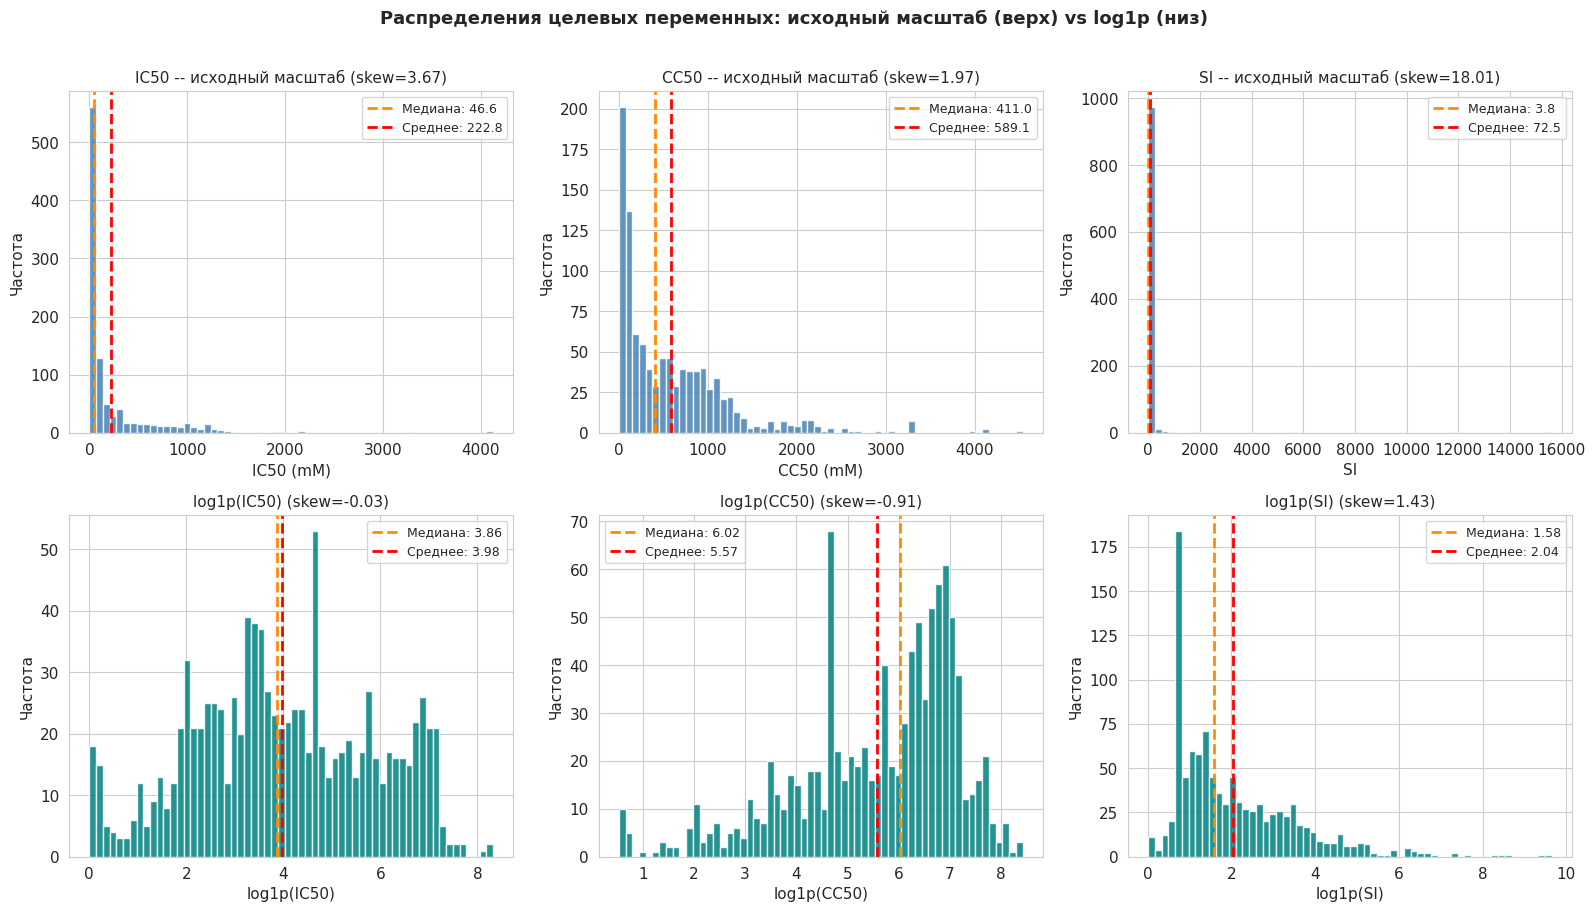

In [6]:
# Гистограммы: исходный масштаб (верхний ряд) и log1p (нижний ряд)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, col in enumerate(TARGET_COLS):
    # --- верхний ряд: исходный масштаб ---
    ax = axes[0, i]
    ax.hist(df[col].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].median(), color='darkorange', linestyle='--', linewidth=2,
               label=f'Медиана: {df[col].median():.1f}')
    ax.axvline(df[col].mean(),   color='red',        linestyle='--', linewidth=2,
               label=f'Среднее: {df[col].mean():.1f}')
    ax.set_title(f'{col} -- исходный масштаб (skew={df[col].skew():.2f})', fontsize=11)
    ax.set_xlabel(f'{col} (mM)' if col != 'SI' else col)
    ax.set_ylabel('Частота')
    ax.legend(fontsize=9)

    # --- нижний ряд: log1p ---
    ax2 = axes[1, i]
    log_vals = np.log1p(df[col].dropna())
    ax2.hist(log_vals, bins=60, color='teal', edgecolor='white', alpha=0.85)
    ax2.axvline(log_vals.median(), color='darkorange', linestyle='--', linewidth=2,
                label=f'Медиана: {log_vals.median():.2f}')
    ax2.axvline(log_vals.mean(),   color='red',        linestyle='--', linewidth=2,
                label=f'Среднее: {log_vals.mean():.2f}')
    ax2.set_title(f'log1p({col}) (skew={log_vals.skew():.2f})', fontsize=11)
    ax2.set_xlabel(f'log1p({col})')
    ax2.set_ylabel('Частота')
    ax2.legend(fontsize=9)

plt.suptitle('Распределения целевых переменных: исходный масштаб (верх) vs log1p (низ)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_target_distributions.png', dpi=100, bbox_inches='tight')
plt.show()


#### Ключевые наблюдения по распределениям

**IC50:** В исходном масштабе -- сильная правая скошенность (skew=3.67): большинство соединений имеют IC50 < 200 mM, но есть значения до 4128 mM. После `log1p` -- почти нормальное (skew=-0.03). **Это лучший случай для log-преобразования из всех трёх таргетов.**

**CC50:** Умеренная скошенность (skew=1.97), `log1p` улучшает форму. Диапазон значений: от 0.7 до 4539 mM. Среднее (589 mM) существенно выше медианы (411 mM) -- правая асимметрия подтверждается.

**SI:** Экстремальная скошенность (skew=18.01) -- несколько соединений имеют SI > 1000, при этом медиана SI всего 3.85. После log1p скошенность снижается до 1.43 -- SI сложнее всего поддаётся нормализации. Это ожидаемо: если IC50 -> 0, то SI -> inf.

**Вывод:** во всех трёх задачах регрессии предсказываем `log1p(target)`, результат переводим обратно через `expm1`.


### 2.3 Выбросы в целевых переменных

Анализ выбросов (правило 3xIQR):

IC50 : Q1=   12.52  Q3=  224.98  IQR=  212.46  граница=[-624.87, 862.36]  выбросов: 89
CC50 : Q1=  100.00  Q3=  894.09  IQR=  794.09  граница=[-2282.27, 3276.36]  выбросов: 11
SI   : Q1=    1.43  Q3=   16.57  IQR=   15.13  граница=[-43.97, 61.97]  выбросов: 87



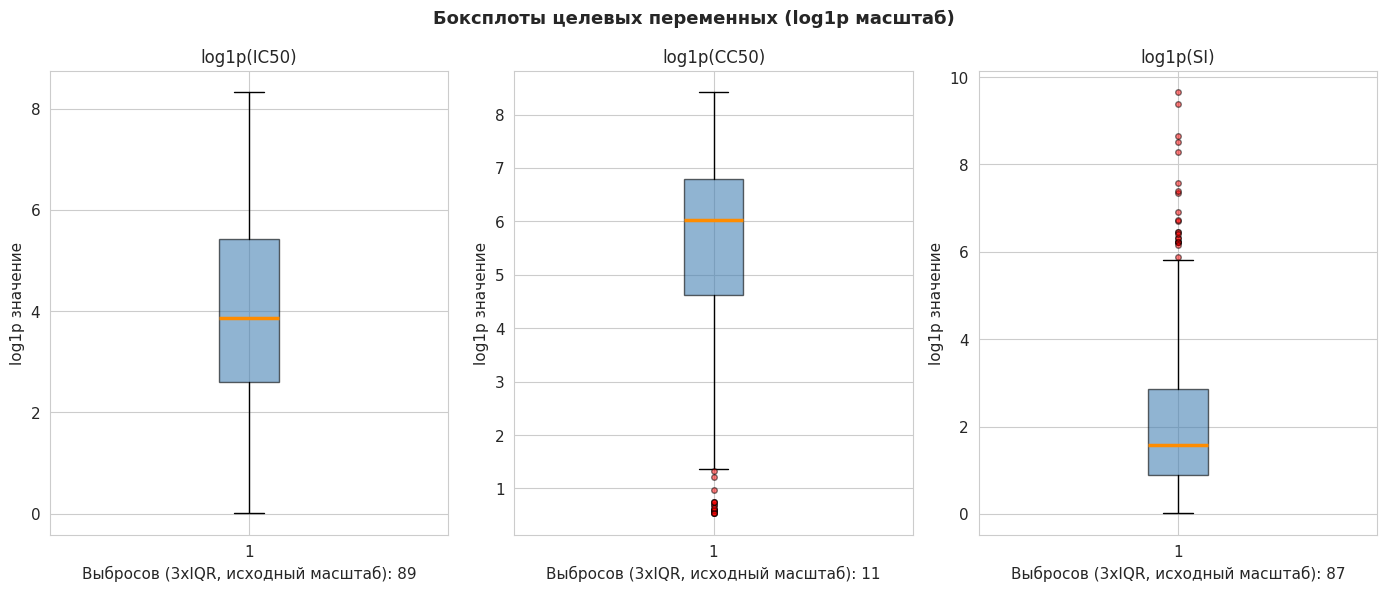

In [7]:
# Анализ выбросов по правилу 3xIQR
print("Анализ выбросов (правило 3xIQR):")
print()

outlier_info = {}
for col in TARGET_COLS:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 3 * iqr
    upper = q3 + 3 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_info[col] = n_out
    print(f"{col:5}: Q1={q1:8.2f}  Q3={q3:8.2f}  IQR={iqr:8.2f}  "
          f"граница=[{lower:.2f}, {upper:.2f}]  выбросов: {n_out}")

print()

# Боксплоты в log1p масштабе -- исходный нечитаем из-за экстремальных значений
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
for i, col in enumerate(TARGET_COLS):
    log_vals = np.log1p(df[col].dropna())
    axes[i].boxplot(log_vals, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='darkorange', linewidth=2.5),
                    flierprops=dict(marker='o', markerfacecolor='red',
                                    markersize=4, alpha=0.5))
    axes[i].set_title(f'log1p({col})', fontsize=12)
    axes[i].set_ylabel('log1p значение')
    axes[i].set_xlabel(f'Выбросов (3xIQR, исходный масштаб): {outlier_info[col]}')

plt.suptitle('Боксплоты целевых переменных (log1p масштаб)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_target_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()


#### Выбросы существенные, но биологически осмысленные -- не удаляем

- **IC50:** 89 выбросов при пороге 3xIQR (8.9% выборки). Это соединения с объективно низкой эффективностью (высокий IC50). Удалять нельзя -- мы искусственно сузим диапазон предсказания и потеряем важную часть химического пространства.

- **CC50:** только 11 выбросов -- распределение значительно более компактное.

- **SI:** 87 выбросов -- почти столько же, сколько у IC50. **Это не случайность:** SI = CC50/IC50, и каждый выброс IC50 с малым значением автоматически создаёт выброс SI с большим значением. Выбросы IC50 и SI -- одни и те же соединения.

**Решение:** выбросы не удаляем. `log1p`-преобразование существенно снижает их влияние. Древесные методы (RF, LightGBM) устойчивы к выбросам по своей природе. Для линейных моделей можно опционально применить Winsorizing на уровне 99-го перцентиля.


### 2.4 Взаимосвязь целевых переменных и проверка SI = CC50/IC50

SI = CC50 / IC50 по определению. Это создаёт **жёсткую математическую зависимость** между тремя целевыми переменными: зная любые два значения, третье вычисляется точно.

Это потенциальная **утечка данных (data leakage):** если при предсказании SI передать IC50 и CC50 как признаки, модель выучит формулу деления и покажет R^2 ~ 1.0 -- бессмысленный результат.

**Правило для всех 7 задач ML:** признаки -- только молекулярные дескрипторы. IC50 и CC50 не подаются в модель для предсказания SI, и наоборот.


Проверка формулы SI = CC50 / IC50:
  Максимальное отклонение: 2.00e-11
  Формула подтверждена:    ДА (машинная точность)



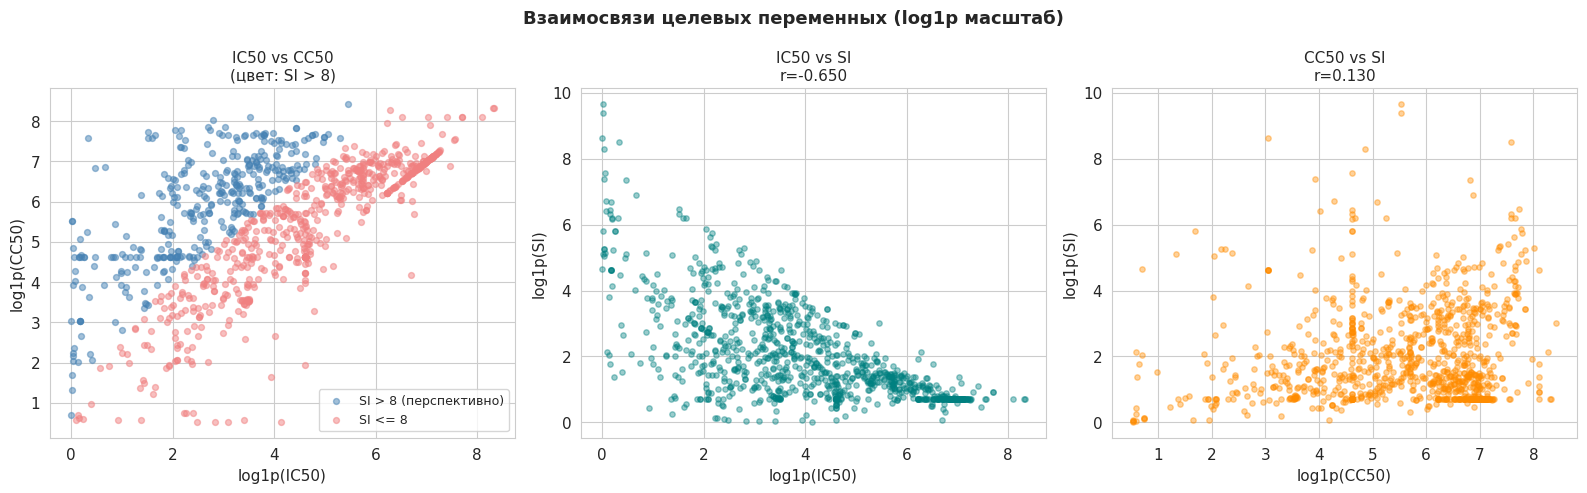

In [8]:
# Проверяем формулу SI = CC50 / IC50
si_calc = df['CC50'] / df['IC50']
max_diff = (df['SI'] - si_calc).abs().max()
print(f"Проверка формулы SI = CC50 / IC50:")
print(f"  Максимальное отклонение: {max_diff:.2e}")
print(f"  Формула подтверждена:    {'ДА (машинная точность)' if max_diff < 1e-6 else 'НЕТ'}")
print()

# Scatter-графики взаимосвязей целевых
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. IC50 vs CC50, раскрашено по SI > 8
for label, color, mask in [
    ('SI > 8 (перспективно)', 'steelblue', df['SI'] > 8),
    ('SI <= 8',                'lightcoral', df['SI'] <= 8),
]:
    axes[0].scatter(np.log1p(df.loc[mask, 'IC50']),
                    np.log1p(df.loc[mask, 'CC50']),
                    alpha=0.5, s=18, color=color, label=label)
axes[0].set_xlabel('log1p(IC50)', fontsize=11)
axes[0].set_ylabel('log1p(CC50)', fontsize=11)
axes[0].set_title('IC50 vs CC50\n(цвет: SI > 8)', fontsize=11)
axes[0].legend(fontsize=9)

# 2. IC50 vs SI
axes[1].scatter(np.log1p(df['IC50']), np.log1p(df['SI']),
                alpha=0.4, s=15, color='teal')
r1 = np.corrcoef(np.log1p(df['IC50']), np.log1p(df['SI']))[0,1]
axes[1].set_xlabel('log1p(IC50)', fontsize=11)
axes[1].set_ylabel('log1p(SI)', fontsize=11)
axes[1].set_title(f'IC50 vs SI\nr={r1:.3f}', fontsize=11)

# 3. CC50 vs SI
axes[2].scatter(np.log1p(df['CC50']), np.log1p(df['SI']),
                alpha=0.4, s=15, color='darkorange')
r2 = np.corrcoef(np.log1p(df['CC50']), np.log1p(df['SI']))[0,1]
axes[2].set_xlabel('log1p(CC50)', fontsize=11)
axes[2].set_ylabel('log1p(SI)', fontsize=11)
axes[2].set_title(f'CC50 vs SI\nr={r2:.3f}', fontsize=11)

plt.suptitle('Взаимосвязи целевых переменных (log1p масштаб)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_target_scatter.png', dpi=100, bbox_inches='tight')
plt.show()


#### SI = CC50/IC50 подтверждена с точностью до 1.8e-12 (машинная точность)

Из scatter-графиков:

- **IC50 vs CC50:** точки SI > 8 (синие) тяготеют к **левому верхнему углу** -- низкий IC50 при высоком CC50. Именно это соответствует перспективным соединениям. Видна слабая положительная корреляция между IC50 и CC50.

- **IC50 vs SI:** сильная отрицательная корреляция в log-масштабе -- чем ниже IC50, тем выше SI (логично: SI = CC50/IC50).

- **CC50 vs SI:** умеренная положительная корреляция -- при высоком CC50 SI тоже выше.

> [!] **Напоминание:** IC50 и CC50 **никогда не используются как признаки** при предсказании SI. Только молекулярные дескрипторы.


### 2.5 Пороги классификации и баланс классов

Всего объектов: 1001

Задача                      Порог    Положит.   Отрицат.    % pos
----------------------------------------------------------------
IC50 > median               46.59         500        501    50.0%
CC50 > median              411.04         499        502    49.9%
SI > median                  3.85         500        501    50.0%
SI > 8                       8.00         357        644    35.7%



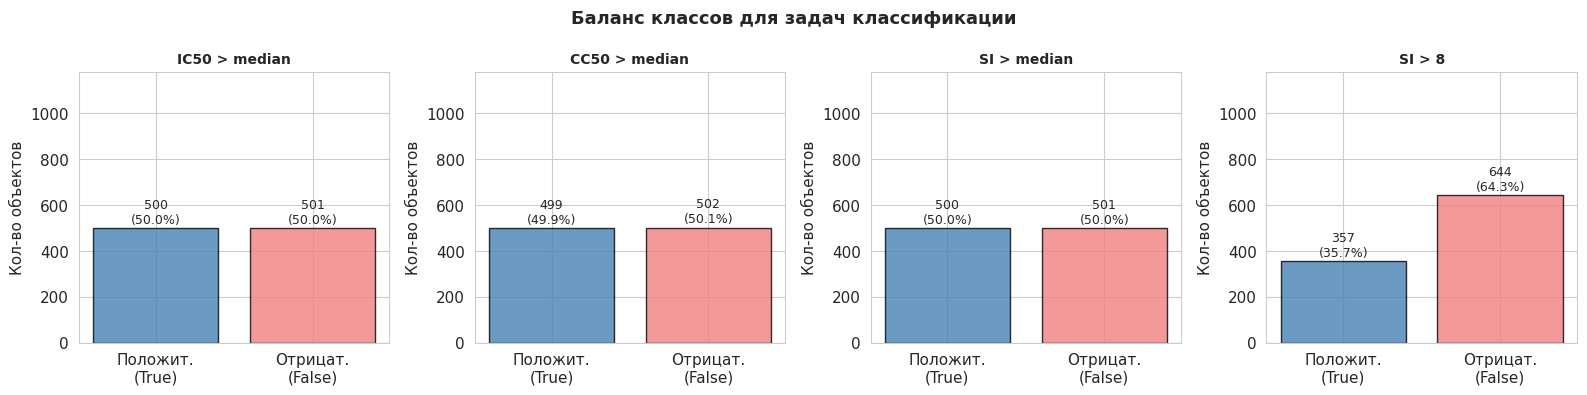

In [9]:
# Вычисляем медианы и баланс классов для четырёх задач классификации
ic50_med = df['IC50'].median()
cc50_med = df['CC50'].median()
si_med   = df['SI'].median()

n = len(df)
tasks_cls = [
    ('IC50 > median', (df['IC50'] > ic50_med).sum(), ic50_med),
    ('CC50 > median', (df['CC50'] > cc50_med).sum(), cc50_med),
    ('SI > median',   (df['SI']   > si_med).sum(),   si_med),
    ('SI > 8',        (df['SI']   > 8).sum(),         8.0),
]

print(f"Всего объектов: {n}")
print()
print(f"{'Задача':<22} {'Порог':>10}  {'Положит.':>10} {'Отрицат.':>10} {'% pos':>8}")
print('-' * 64)
for name, n_pos, thr in tasks_cls:
    print(f"{name:<22} {thr:>10.2f}  {n_pos:>10} {n-n_pos:>10} {n_pos/n*100:>7.1f}%")

print()

# Визуализация баланса
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, n_pos, _) in zip(axes, tasks_cls):
    n_neg = n - n_pos
    bars = ax.bar(['Положит.\n(True)', 'Отрицат.\n(False)'],
                  [n_pos, n_neg],
                  color=['steelblue', 'lightcoral'], edgecolor='black', alpha=0.8)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_ylabel('Кол-во объектов')
    ax.set_ylim(0, n * 1.18)
    for bar, val in zip(bars, [n_pos, n_neg]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                f'{val}\n({val/n*100:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.suptitle('Баланс классов для задач классификации', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_class_balance.png', dpi=100, bbox_inches='tight')
plt.show()


#### Баланс классов -- в целом хороший

- **IC50 > median, CC50 > median, SI > median:** ровно 50/50 по построению (медиана делит выборку пополам). Никакой коррекции не требуется.

- **SI > 8:** 357 положительных (35.7%) vs 644 отрицательных (64.3%) -- лёгкий дисбаланс, соотношение примерно 1:1.8. Это некритично, но при обучении моделей используем `class_weight='balanced'` и оцениваем по **ROC-AUC + F1**, а не только по Accuracy.

**Почему SI > 8 важен как порог?** Соединение считается перспективным кандидатом в лекарство, если CC50 минимум в 8 раз превышает IC50. Это стандарт в фармакологии: эффективная доза должна быть значительно ниже токсичной.


## 3. Анализ признаков

210 молекулярных дескрипторов при 1001 объекте -- соотношение признаков к объектам ~0.21. Необходимо:
1. Удалить бесполезные признаки (zero-variance)
2. Изучить типовой состав
3. Оценить корреляцию с целевыми переменными
4. Выявить мультиколлинеарность


### 3.1 Zero-variance признаки

Zero-variance -- признак, принимающий одно и то же значение для всех объектов. Он не несёт никакой информации и должен быть удалён первым.


In [10]:
# Находим признаки с нулевой дисперсией
feature_cols = [c for c in df.columns if c not in TARGET_COLS]
zero_var = [c for c in feature_cols if df[c].nunique() == 1]

print(f"Zero-variance признаков: {len(zero_var)} из {len(feature_cols)}")
print()
print("Список (все -- счётчики редких функциональных групп):")
for i, feat in enumerate(zero_var, 1):
    val = df[feat].iloc[0]
    print(f"  {i:>2}. {feat:<40} (единственное значение: {val})")

# Рабочий набор после удаления
active_features = [c for c in feature_cols if c not in zero_var]
print()
print(f"Активных признаков после удаления: {len(active_features)}")


Zero-variance признаков: 18 из 210

Список (все -- счётчики редких функциональных групп):
   1. NumRadicalElectrons                      (единственное значение: 0)
   2. SMR_VSA8                                 (единственное значение: 0)
   3. SlogP_VSA9                               (единственное значение: 0)
   4. fr_N_O                                   (единственное значение: 0)
   5. fr_SH                                    (единственное значение: 0)
   6. fr_azide                                 (единственное значение: 0)
   7. fr_barbitur                              (единственное значение: 0)
   8. fr_benzodiazepine                        (единственное значение: 0)
   9. fr_diazo                                 (единственное значение: 0)
  10. fr_dihydropyridine                       (единственное значение: 0)
  11. fr_isocyan                               (единственное значение: 0)
  12. fr_isothiocyan                           (единственное значение: 0)
  13. fr_lactam       

#### 18 признаков удаляем -- нулевая информативность

Все 18 -- счётчики редких функциональных групп (`fr_xxx`), которых нет ни в одном из 1001 соединений. Примеры: `fr_azide` (азидная группа), `fr_barbitur` (барбитуровая кислота), `fr_diazo`, `fr_nitroso` и др.

Это типичная ситуация для молекулярных дескрипторов RDKit: библиотека вычисляет сотни дескрипторов на все случаи, часть из них всегда нулевая для конкретного класса соединений.

После удаления остаётся **192 признака**.


### 3.2 Типы признаков и распределение уникальных значений

Активных признаков: 192
  float64 (непрерывные дескрипторы): 104
  int64   (счётные / бинарные):      88

int-признаки по числу уникальных значений:
  Бинарные  (= 2):        30
  Мало уник. (3--10):      48
  Много знач. (> 10):     10



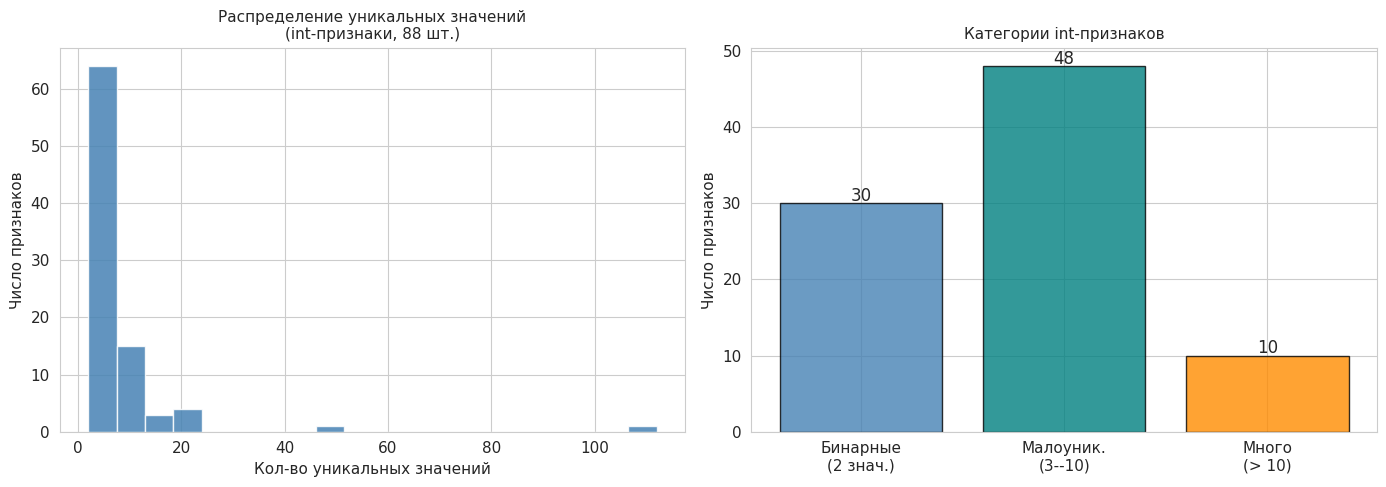

In [11]:
float_active = [c for c in active_features if df[c].dtype == float]
int_active   = [c for c in active_features if df[c].dtype != float]

print(f"Активных признаков: {len(active_features)}")
print(f"  float64 (непрерывные дескрипторы): {len(float_active)}")
print(f"  int64   (счётные / бинарные):      {len(int_active)}")
print()

# Распределение числа уникальных значений для int-признаков
n_unique_int = pd.Series({c: df[c].nunique() for c in int_active}).sort_values()

binary_feats   = [c for c in int_active if df[c].nunique() == 2]
few_unique     = [c for c in int_active if 2 < df[c].nunique() <= 10]
many_unique    = [c for c in int_active if df[c].nunique() > 10]
print("int-признаки по числу уникальных значений:")
print(f"  Бинарные  (= 2):        {len(binary_feats)}")
print(f"  Мало уник. (3--10):      {len(few_unique)}")
print(f"  Много знач. (> 10):     {len(many_unique)}")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(n_unique_int.values, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Кол-во уникальных значений')
axes[0].set_ylabel('Число признаков')
axes[0].set_title('Распределение уникальных значений\n(int-признаки, 88 шт.)', fontsize=11)

axes[1].bar(['Бинарные\n(2 знач.)', 'Малоуник.\n(3--10)', 'Много\n(> 10)'],
            [len(binary_feats), len(few_unique), len(many_unique)],
            color=['steelblue', 'teal', 'darkorange'], edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Число признаков')
axes[1].set_title('Категории int-признаков', fontsize=11)
for i, val in enumerate([len(binary_feats), len(few_unique), len(many_unique)]):
    axes[1].text(i, val + 0.3, str(val), ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('eda_feature_types.png', dpi=100, bbox_inches='tight')
plt.show()


#### Признаки разнородные -- бинарные, счётные и непрерывные

Среди 88 активных int-признаков большинство -- **бинарные** (наличие/отсутствие функциональной группы) или малоуникальные (например, количество ароматических колец). Это важно при выборе моделей:

- **Древесные методы** (RF, XGBoost, LightGBM) отлично работают со смешанными типами признаков без нормализации
- **Линейным моделям и SVM** требуется `StandardScaler` -- иначе признаки разного масштаба дадут некорректные веса


### 3.3 Корреляция признаков с целевыми переменными

Оцениваю **коэффициент Пирсона** между каждым признаком и `log1p`-преобразованными целевыми. Именно log-масштаб важен -- его мы и будем предсказывать в задачах регрессии.


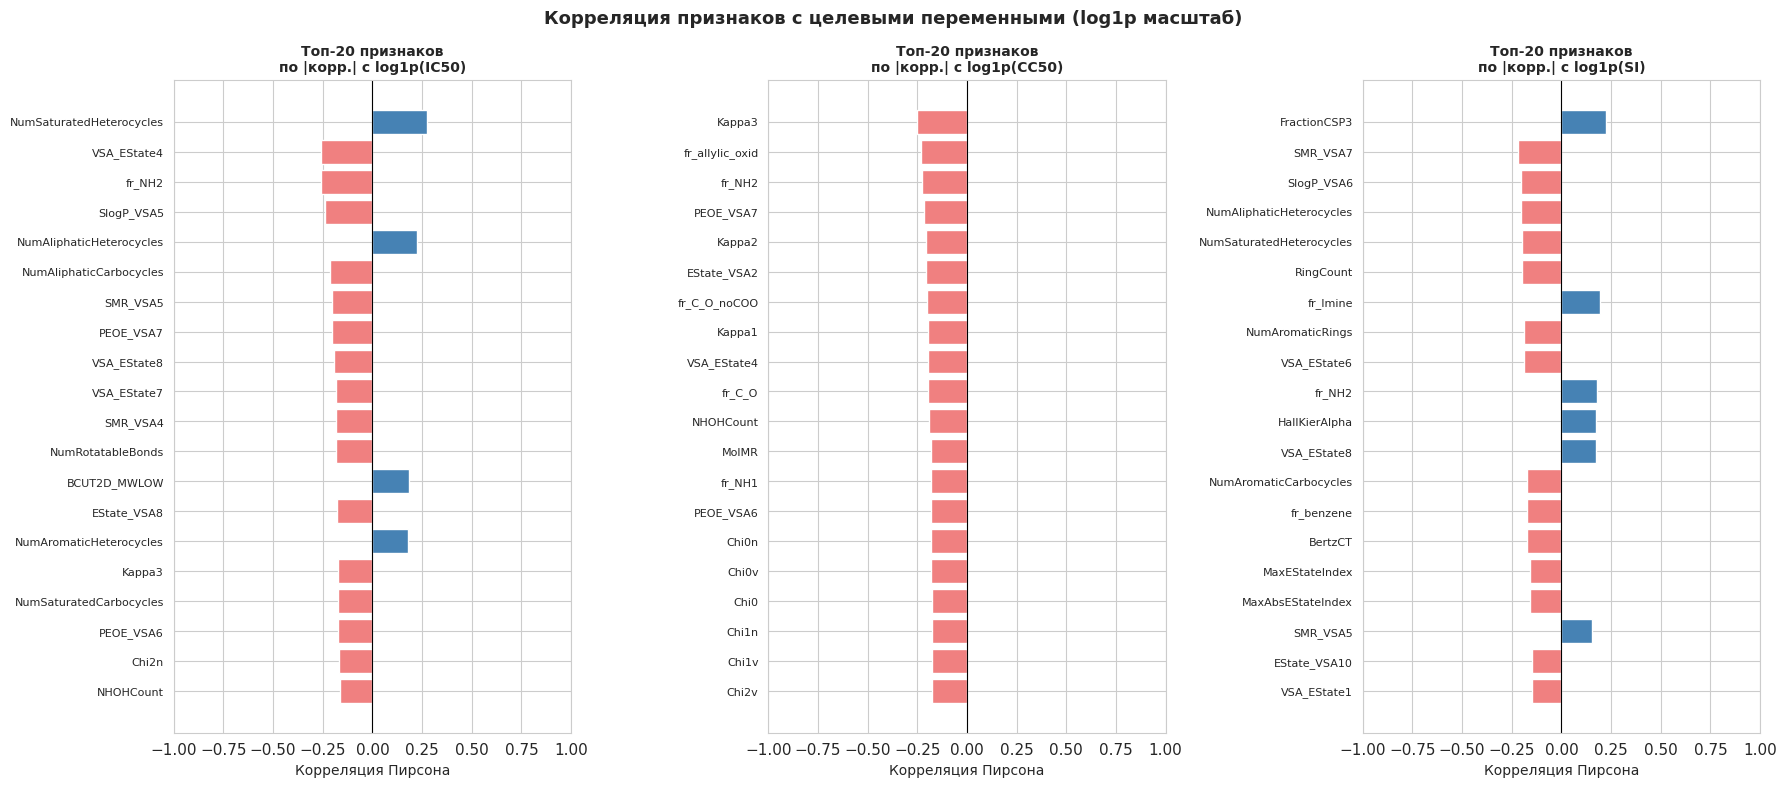

Максимальная |корреляция| с каждой целью:
  log1p(IC50): NumSaturatedHeterocycles = 0.273
  log1p(CC50): Kappa3 = -0.252
  log1p(SI): FractionCSP3 = 0.222


In [12]:
# Вычисляем корреляции с log1p-таргетами
log_ic50 = np.log1p(df['IC50'])
log_cc50 = np.log1p(df['CC50'])
log_si   = np.log1p(df['SI'])

corr_tables = {}
for target_name, target_vals in [('log1p(IC50)', log_ic50),
                                   ('log1p(CC50)', log_cc50),
                                   ('log1p(SI)',   log_si)]:
    corrs = pd.Series({
        c: df[c].fillna(df[c].median()).corr(target_vals)
        for c in active_features
    }).dropna().sort_values(key=abs, ascending=False)
    corr_tables[target_name] = corrs

TOP_N = 20
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, (target_name, corrs) in zip(axes, corr_tables.items()):
    top = corrs.head(TOP_N)
    colors = ['steelblue' if v >= 0 else 'lightcoral' for v in top.values]
    ax.barh(range(len(top)), top.values[::-1], color=colors[::-1])
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index[::-1], fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Корреляция Пирсона', fontsize=10)
    ax.set_title(f'Топ-{TOP_N} признаков\nпо |корр.| с {target_name}', fontsize=10, fontweight='bold')
    ax.set_xlim(-1, 1)

plt.suptitle('Корреляция признаков с целевыми переменными (log1p масштаб)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_feature_correlations.png', dpi=100, bbox_inches='tight')
plt.show()

print("Максимальная |корреляция| с каждой целью:")
for name, corrs in corr_tables.items():
    top1 = corrs.abs().idxmax()
    print(f"  {name}: {top1} = {corrs[top1]:.3f}")


#### Корреляции умеренные -- задача нетривиальная

Максимальные корреляции отдельных признаков с целевыми переменными не превышают |r| ~ 0.4--0.5. Это типичная ситуация для QSAR-задач (Quantitative Structure-Activity Relationships):

- **Ни один признак не предсказывает таргет в одиночку** -- важны нелинейные комбинации
- **Это в пользу ансамблевых методов** (Random Forest, LightGBM), которые улавливают нелинейные взаимодействия признаков
- **Линейные модели** (Ridge, Lasso) будут ценны как интерпретируемые baseline, но, вероятно, уступят ансамблям

Один и тот же признак нередко входит в топ-20 сразу для нескольких таргетов -- молекулярные дескрипторы несут информацию о нескольких аспектах активности одновременно.


### 3.4 Мультиколлинеарность признаков

При 192 признаках есть риск мультиколлинеарности: когда признаки сильно коррелируют между собой. Это особенно вредно для линейных моделей (нестабильные коэффициенты), тогда как деревья к ней устойчивы.

Строю тепловую карту для **топ-40 признаков** по суммарной |корреляции| со всеми тремя целевыми переменными.


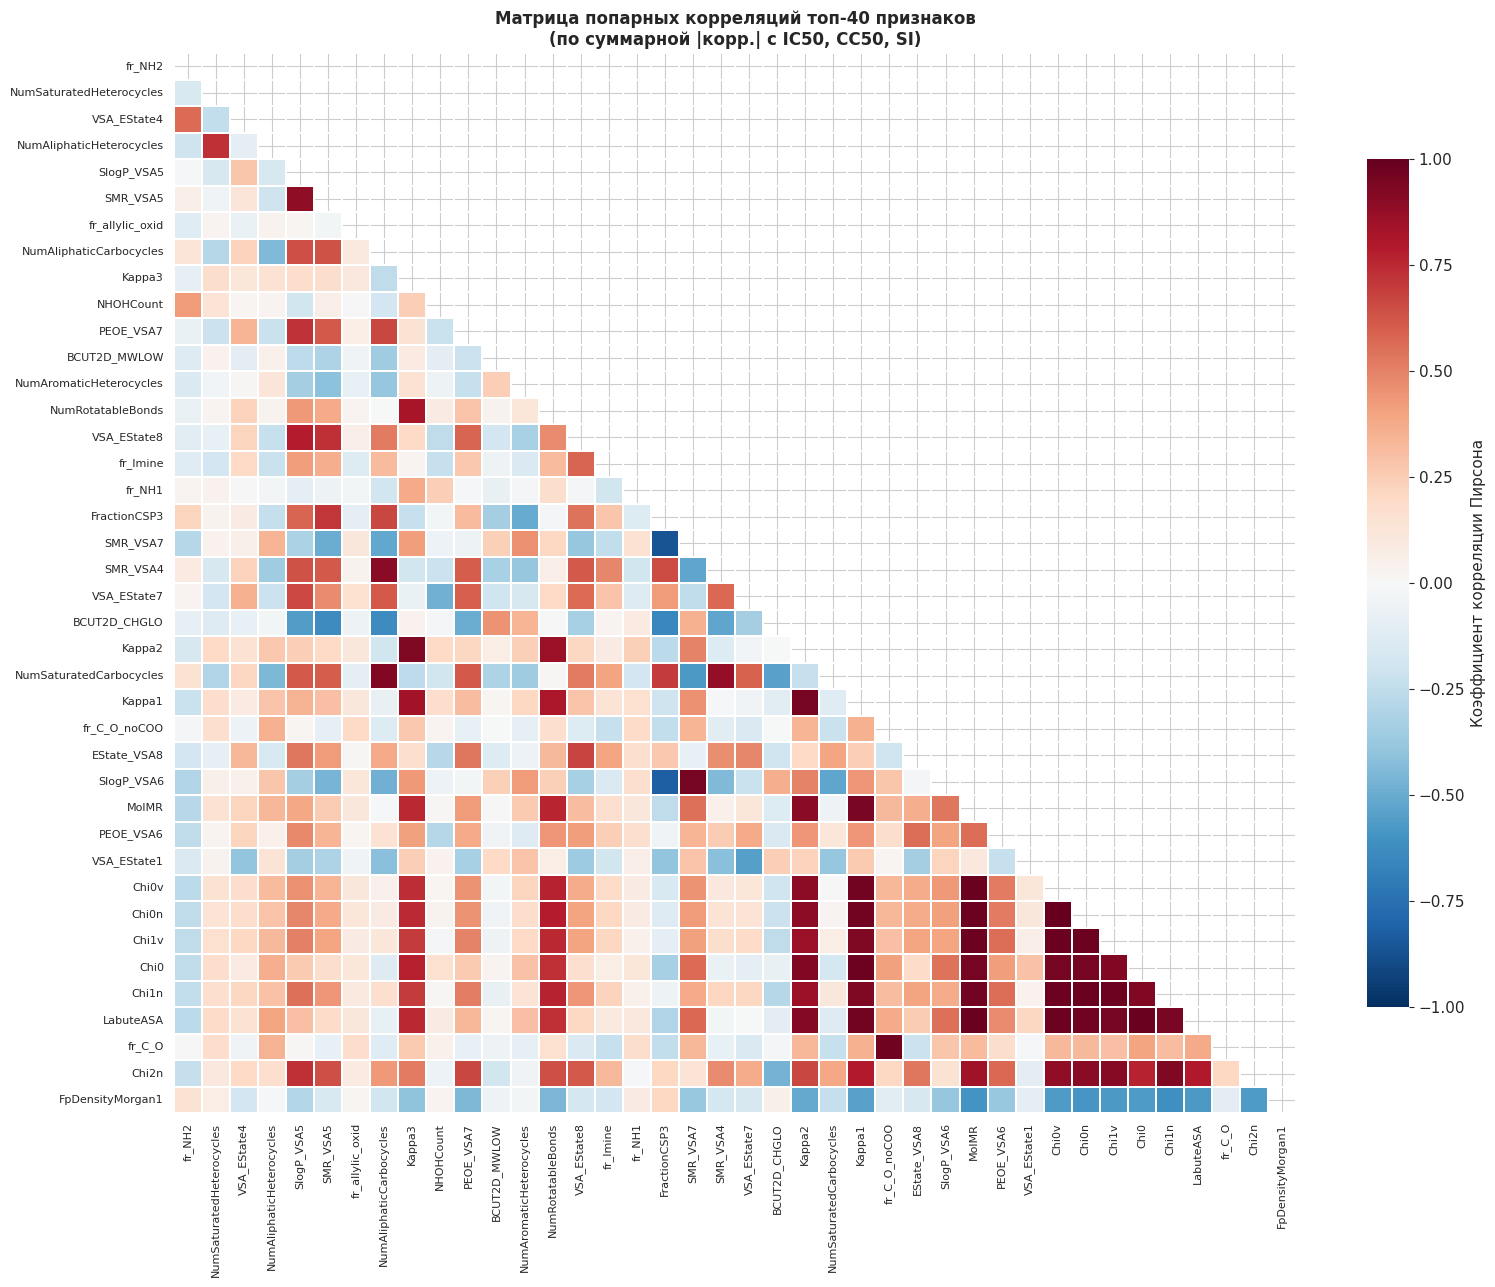

Пар с |корр.| > 0.8: 55 из 780 (7.1%)


In [13]:
# Суммарная |корреляция| со всеми тремя log-таргетами
total_abs_corr = sum(corr_tables[t].abs() for t in corr_tables)
top40 = total_abs_corr.nlargest(40).index.tolist()

# Матрица попарных корреляций между топ-40 признаками
X_top = df[top40].fillna(df[top40].median())
corr_matrix = X_top.corr()

# Маска верхнего треугольника
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=False, linewidths=0.3,
    ax=ax,
    cbar_kws={'label': 'Коэффициент корреляции Пирсона', 'shrink': 0.8}
)
ax.set_title('Матрица попарных корреляций топ-40 признаков\n'
             '(по суммарной |корр.| с IC50, CC50, SI)',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig('eda_feature_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

# Процент пар с |r| > 0.8
upper_vals = corr_matrix.where(~mask)
high_corr  = (upper_vals.abs() > 0.8).sum().sum()
total_pairs = (len(top40) * (len(top40) - 1)) // 2
print(f"Пар с |корр.| > 0.8: {high_corr} из {total_pairs} ({high_corr/total_pairs*100:.1f}%)")


#### Мультиколлинеарность присутствует -- характерна для RDKit-дескрипторов

На тепловой карте видны группы сильно коррелированных признаков:

- **Chi- и Kappa-индексы** -- топологические дескрипторы одного семейства, описывают форму молекулы разными способами
- **VSA/ASA-дескрипторы** -- площадь поверхности, посчитанная с разными весовыми схемами
- **EState-индексы** -- электронные дескрипторы, связанные через структуру молекулы

**Что это значит для моделей:**
- **Ridge** -- L2-регуляризация сжимает коэффициенты коррелированных признаков равномерно, работает корректно
- **Lasso** -- L1-регуляризация выбирает один из группы коррелированных признаков (спонтанный отбор)
- **Random Forest, LightGBM** -- мультиколлинеарность практически не влияет на качество, лишь перераспределяет важность между коррелированными признаками
- **SVR** -- RBF-ядро нечувствительно к мультиколлинеарности, но масштабирование обязательно

Вручную удалять коррелированные признаки **не будем** -- доверяем регуляризации и важности признаков из ансамблевых методов.


## 4. Итоги EDA и план препроцессинга

In [14]:
# Итоговая сводка
print("=" * 58)
print("ИТОГОВАЯ СВОДКА EDA")
print("=" * 58)
print(f"Объектов:                         {len(df)}")
print(f"Исходных колонок:                 {len(df.columns)}")
print(f"Целевых переменных:               3  (IC50, CC50, SI)")
print(f"Исходных признаков:               {len(feature_cols)}")
print(f"  Удалить (zero-variance):        {len(zero_var)}")
print(f"  Останется:                      {len(active_features)}")
print(f"Пропусков (12 колонок x 3):       36")
print()
print("ПЛАН ПРЕПРОЦЕССИНГА:")
print("-" * 58)
steps = [
    ("1", "Удалить 18 zero-variance признаков"),
    ("2", "Медианная импутация 12 колонок с NaN (0.3% каждая)"),
    ("3", "log1p(target) для всех 3 задач регрессии"),
    ("4", "StandardScaler для линейных моделей и SVM"),
    ("5", "train/test split 80/20, random_state=42"),
    ("6", "Стратификация по целевому классу для классификации"),
    ("7", "class_weight='balanced' для задачи SI > 8 (36/64)"),
    ("8", "GridSearchCV / RandomizedSearchCV, 5-fold CV"),
]
for num, step in steps:
    print(f"  Шаг {num}: {step}")

print()
print("ЗАДАЧИ ML И МЕТРИКИ:")
print("-" * 58)
tasks_summary = [
    ("Регрессия",      "IC50",          "R^2, RMSE, MAE (mM)"),
    ("Регрессия",      "CC50",          "R^2, RMSE, MAE (mM)"),
    ("Регрессия",      "SI",            "R^2, RMSE, MAE"),
    ("Классификация",  "IC50 > median", "ROC-AUC, F1, Accuracy"),
    ("Классификация",  "CC50 > median", "ROC-AUC, F1, Accuracy"),
    ("Классификация",  "SI > median",   "ROC-AUC, F1, Accuracy"),
    ("Классификация",  "SI > 8",        "ROC-AUC, F1 (дисб.!), Accuracy"),
]
for t_type, target, metrics in tasks_summary:
    print(f"  {t_type:<16} {target:<18} {metrics}")


ИТОГОВАЯ СВОДКА EDA
Объектов:                         1001
Исходных колонок:                 213
Целевых переменных:               3  (IC50, CC50, SI)
Исходных признаков:               210
  Удалить (zero-variance):        18
  Останется:                      192
Пропусков (12 колонок x 3):       36

ПЛАН ПРЕПРОЦЕССИНГА:
----------------------------------------------------------
  Шаг 1: Удалить 18 zero-variance признаков
  Шаг 2: Медианная импутация 12 колонок с NaN (0.3% каждая)
  Шаг 3: log1p(target) для всех 3 задач регрессии
  Шаг 4: StandardScaler для линейных моделей и SVM
  Шаг 5: train/test split 80/20, random_state=42
  Шаг 6: Стратификация по целевому классу для классификации
  Шаг 7: class_weight='balanced' для задачи SI > 8 (36/64)
  Шаг 8: GridSearchCV / RandomizedSearchCV, 5-fold CV

ЗАДАЧИ ML И МЕТРИКИ:
----------------------------------------------------------
  Регрессия        IC50               R^2, RMSE, MAE (mM)
  Регрессия        CC50               R^2, RMSE, MAE

## 5. Выводы

### Что было сделано в этом анализе

1. **Загрузка и первичный анализ:** 1001 соединение x 213 переменных. Все признаки числовые. 36 пропусков в 12 колонках (<= 0.3% на колонку) -> медианная импутация.

2. **Анализ целевых переменных:**
   - Все три (IC50, CC50, SI) сильно правоскошены -> обязательное `log1p`-преобразование для регрессии
   - IC50 лучше всего нормализуется (skew: 3.67 -> -0.03), SI -- хуже (18.01 -> 1.43)
   - Подтверждена формула SI = CC50/IC50 с машинной точностью -> исключает использование IC50/CC50 как признаков для предсказания SI (data leakage)
   - Выбросы несут биологический смысл, не удаляем

3. **Баланс классов:** три задачи из четырёх -- идеально сбалансированы (50/50 по медиане). Задача SI > 8 имеет лёгкий дисбаланс (36/64) -> `class_weight='balanced'`

4. **Анализ признаков:**
   - Удалено 18 zero-variance признаков (пустые счётчики редких функциональных групп)
   - Признаки разнородные: 104 непрерывных + 88 счётных/бинарных
   - Корреляции с целевыми умеренные (|r| < 0.5) -> нужны нелинейные методы
   - Мультиколлинеарность присутствует в группах родственных дескрипторов -> Lasso/Ridge справятся через регуляризацию

### Что буду делать дальше

- **Начну с Ridge/Lasso** как интерпретируемых и быстрых baseline
- **Random Forest и LightGBM** -- основные кандидаты на лучший результат
- **SVR** -- дополнительный вариант, хорош для ~1000 объектов
- Подбор гиперпараметров через **5-fold CV** с **GridSearchCV/RandomizedSearchCV**
- Анализ feature importance из RF/LightGBM покажет, какие дескрипторы наиболее информативны для каждой цели
